# Experiment 05: Retrieval Strategy Comparison

## Objective

The objective of this experiment is to compare two widely used retrieval
strategies in Retrieval-Augmented Generation (RAG) systems:

- Similarity Search
- Maximal Marginal Relevance (MMR)

Both retrieval strategies are evaluated using the same embedding model
(BAAI/bge-m3), document chunks, vector database, and retrieval query to
ensure a fair comparison.

---

## Evaluation Metrics

- Average Retrieval Time
- Retrieved Documents
- Unique Pages
- Duplicate Chunks
- Context Diversity Score

---

## Expected Outcome

Identify which retrieval strategy provides the best balance between
retrieval speed and contextual diversity for a production-level
RAG pipeline.

In [1]:
from config.settings import (
    PDF_PATH,
    DEFAULT_QUERY,
)

from loaders.pdf_loader import load_pdf
from splitters.text_splitter import split_documents
from embeddings.embedding_model import get_embedding_model

from vectorstores.chroma_store import create_chroma_vectorstore

from retrieval.similarity import get_similarity_retriever
from retrieval.mmr import get_mmr_retriever

from evaluation.comparison import compare_retrieval_strategies

from utils.printer import print_summary

import pandas as pd
import matplotlib.pyplot as plt

c:\Users\Sehar Malik\Desktop\ai-engineer-internship-xeven-solutions-2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
documents = load_pdf(PDF_PATH)

print(f"Documents Loaded: {len(documents)}")

Documents Loaded: 63


In [3]:
chunks = split_documents(documents)

print(f"Chunks Created: {len(chunks)}")

Chunks Created: 148


In [4]:
embedding_model = get_embedding_model()

print("Embedding model loaded successfully.")

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 42228.16it/s]


Embedding model loaded successfully.


In [5]:
vectorstore = create_chroma_vectorstore(
    chunks,
    embedding_model,
)

print("ChromaDB vector store created.")

ChromaDB vector store created.


In [6]:
similarity_retriever = get_similarity_retriever(
    vectorstore,
)

print("Similarity Search retriever created.")

Similarity Search retriever created.


In [7]:
mmr_retriever = get_mmr_retriever(
    vectorstore,
)

print("MMR retriever created.")

MMR retriever created.


In [8]:
results = compare_retrieval_strategies(
    similarity_retriever=similarity_retriever,
    mmr_retriever=mmr_retriever,
    query=DEFAULT_QUERY,
)

In [9]:
print_summary(
    results=results,
    total_chunks=len(chunks),
)


EXPERIMENT 05: RETRIEVAL STRATEGY COMPARISON
Similarity Search vs Maximal Marginal Relevance (MMR)

Experiment Configuration
----------------------------------------------------------------------
Embedding Model : BAAI/bge-m3
Chunk Size      : 1000
Chunk Overlap   : 200
Top-K           : 5
Benchmark Runs  : 10
Total Chunks    : 148

Similarity Search
--------------------------------------------------
Average Retrieval Time : 0.2721 seconds
Retrieved Documents    : 5
Unique Pages           : 2
Duplicate Chunks       : 3
Context Diversity      : 0.40

MMR
--------------------------------------------------
Average Retrieval Time : 0.2475 seconds
Retrieved Documents    : 5
Unique Pages           : 4
Duplicate Chunks       : 0
Context Diversity      : 1.00

ENGINEERING DECISION
✓ Faster Retrieval     : MMR
✓ Better Diversity     : MMR
✓ Fewer Duplicates     : MMR

Production Considerations:
- Similarity Search: Faster and computationally efficient.
- MMR: Produces more diverse context whil

In [10]:
comparison_df = pd.DataFrame(
    {
        "Metric": [
            "Average Retrieval Time (s)",
            "Retrieved Documents",
            "Unique Pages",
            "Duplicate Chunks",
            "Context Diversity",
        ],
        "Similarity Search": [
            results["Similarity Search"][
                "average_retrieval_time_seconds"
            ],
            results["Similarity Search"][
                "retrieved_documents"
            ],
            results["Similarity Search"][
                "unique_pages"
            ],
            results["Similarity Search"][
                "duplicate_chunks"
            ],
            results["Similarity Search"][
                "context_diversity_score"
            ],
        ],
        "MMR": [
            results["MMR"][
                "average_retrieval_time_seconds"
            ],
            results["MMR"][
                "retrieved_documents"
            ],
            results["MMR"][
                "unique_pages"
            ],
            results["MMR"][
                "duplicate_chunks"
            ],
            results["MMR"][
                "context_diversity_score"
            ],
        ],
    }
)

comparison_df

,Metric,Similarity Search,MMR
0,Average Retrieval Time (s),0.272106,0.247527
1,Retrieved Documents,5.000000,5.000000
2,Unique Pages,2.000000,4.000000
3,Duplicate Chunks,3.000000,0.000000
4,Context Diversity,0.400000,1.000000


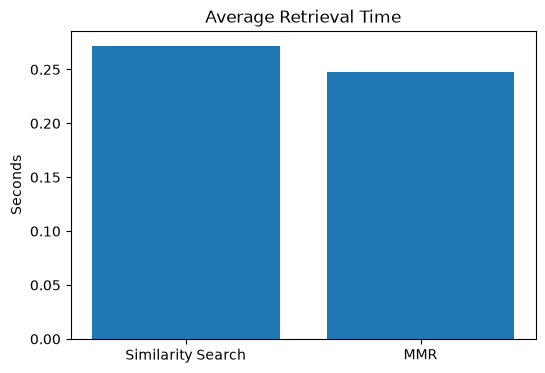

In [11]:
plt.figure(figsize=(6, 4))

plt.bar(
    ["Similarity Search", "MMR"],
    [
        results["Similarity Search"][
            "average_retrieval_time_seconds"
        ],
        results["MMR"][
            "average_retrieval_time_seconds"
        ],
    ],
)

plt.title("Average Retrieval Time")
plt.ylabel("Seconds")

plt.show()

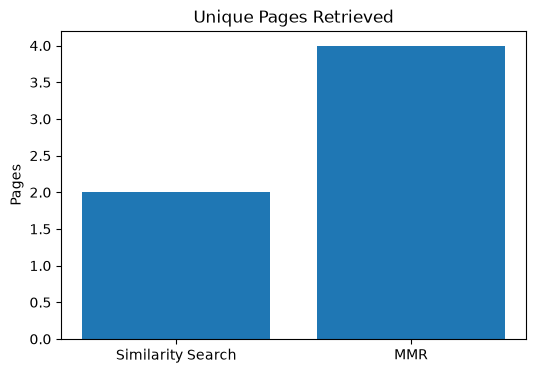

In [12]:
plt.figure(figsize=(6, 4))

plt.bar(
    ["Similarity Search", "MMR"],
    [
        results["Similarity Search"][
            "unique_pages"
        ],
        results["MMR"][
            "unique_pages"
        ],
    ],
)

plt.title("Unique Pages Retrieved")
plt.ylabel("Pages")

plt.show()

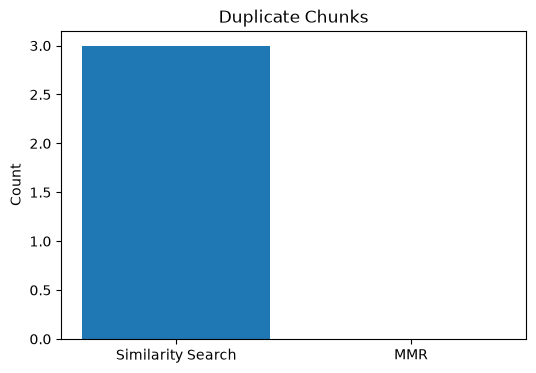

In [13]:
plt.figure(figsize=(6, 4))

plt.bar(
    ["Similarity Search", "MMR"],
    [
        results["Similarity Search"][
            "duplicate_chunks"
        ],
        results["MMR"][
            "duplicate_chunks"
        ],
    ],
)

plt.title("Duplicate Chunks")
plt.ylabel("Count")

plt.show()

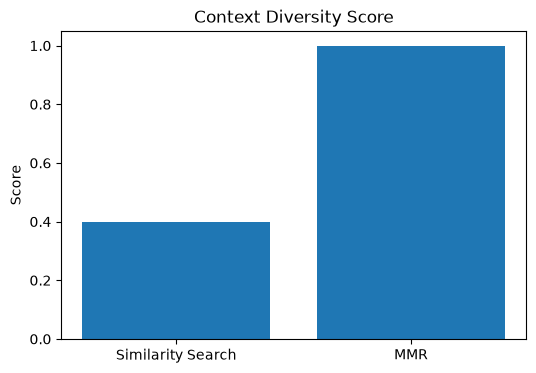

In [14]:
plt.figure(figsize=(6, 4))

plt.bar(
    ["Similarity Search", "MMR"],
    [
        results["Similarity Search"][
            "context_diversity_score"
        ],
        results["MMR"][
            "context_diversity_score"
        ],
    ],
)

plt.title("Context Diversity Score")
plt.ylabel("Score")

plt.show()

# Engineering Observations

## Similarity Search

### Advantages

- Retrieves the most semantically similar chunks.
- Computationally efficient.
- Simple retrieval strategy.
- Suitable for latency-sensitive applications.

### Limitations

- Frequently retrieves redundant chunks.
- Lower contextual diversity.
- Multiple results may originate from the same document region.

---

## Maximal Marginal Relevance (MMR)

### Advantages

- Produces more diverse retrieval results.
- Reduces redundant document chunks.
- Retrieves information from a wider range of document pages.
- Improves contextual coverage for downstream Large Language Models.

### Limitations

- Slightly more computationally complex than Similarity Search.

---

# Engineering Decision

Based on the experimental evaluation:

- MMR retrieved documents from more unique pages.
- MMR eliminated duplicate chunks.
- MMR achieved a higher context diversity score.
- Retrieval latency remained comparable to Similarity Search.

Therefore, **Maximal Marginal Relevance (MMR)** is selected as the preferred retrieval strategy for the production RAG pipeline because it provides broader contextual coverage while maintaining efficient retrieval performance.